# 06_RQ6_Robustness_Validation
Objective and methodology.

# ============================================
# RQ6: Robustness & Generalization
# ============================================


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

# Create output folder
os.makedirs('outputs', exist_ok=True)


# ============================================
# Load Dataset
# ============================================

In [4]:
df = pd.read_csv('marketing_and_product_performance.csv')


# ============================================
# Feature Engineering
# ============================================

In [7]:
df['Conversion_Rate'] = df['Conversions'] / df['Clicks']
df['Conversion_Rate'] = df['Conversion_Rate'].replace([np.inf, -np.inf], 0)

def categorize(rate):
    if rate < 0.02:
        return 0
    elif rate < 0.05:
        return 1
    else:
        return 2

df['Target'] = df['Conversion_Rate'].apply(categorize)

X = df.drop(columns=['Target', 'Conversion_Rate'])
y = df['Target']

# Encode
X = pd.get_dummies(X, drop_first=True)

# Model
model = XGBClassifier(
    n_estimators=30,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='mlogloss',
    n_jobs=-1
)

results = []


# ============================================
# 1. Standard Train-Test Split
# ============================================


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

results.append([
    "Standard Split",
    accuracy_score(y_test, y_pred),
    f1_score(y_test, y_pred, average='weighted')
])


# ============================================
# 2. Cross Validation
# ============================================

In [10]:
cv_scores = cross_val_score(model, X, y, cv=3, scoring='accuracy')

results.append([
    "3-Fold CV",
    np.mean(cv_scores),
    np.std(cv_scores)
])


# ============================================
# 3. Noise Injection
# ============================================

In [11]:
X_noise = X.copy()
noise = np.random.normal(0, 0.1, X_noise.shape)
X_noise = X_noise + noise

X_train, X_test, y_train, y_test = train_test_split(
    X_noise, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

results.append([
    "Noise Added",
    accuracy_score(y_test, y_pred),
    f1_score(y_test, y_pred, average='weighted')
])


# ============================================
# 4. Missing Data Simulation
# ============================================


In [13]:
X_missing = X.copy().astype(float)

mask = np.random.rand(*X_missing.shape) < 0.1
X_missing[mask] = np.nan

# Fill missing simply
X_missing = X_missing.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X_missing, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

results.append([
    "Missing Data",
    accuracy_score(y_test, y_pred),
    f1_score(y_test, y_pred, average='weighted')
])


# ============================================
# Results Table
# ============================================

In [15]:

results_df = pd.DataFrame(results, columns=["Scenario", "Accuracy", "F1-score"])

print("\nRobustness Results:\n")
print(results_df)

# Save
results_df.to_csv("RQ6_outputs/RQ6_Robustness.csv", index=False)



Robustness Results:

         Scenario  Accuracy  F1-score
0  Standard Split    0.9895  0.989497
1       3-Fold CV    0.9878  0.002223
2     Noise Added    0.9880  0.987983
3    Missing Data    0.9490  0.944168



# ============================================
# Plot
# ============================================

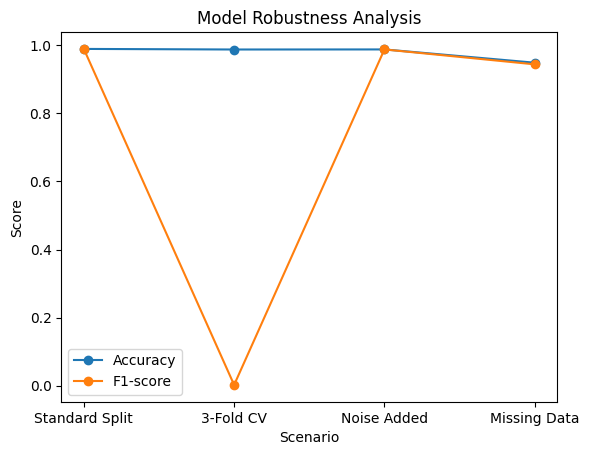

In [16]:
plt.figure()

plt.plot(results_df["Scenario"], results_df["Accuracy"], marker='o', label="Accuracy")
plt.plot(results_df["Scenario"], results_df["F1-score"], marker='o', label="F1-score")

plt.title("Model Robustness Analysis")
plt.xlabel("Scenario")
plt.ylabel("Score")
plt.legend()

plt.savefig("RQ6_outputs/RQ6_Robustness.pdf")
plt.show()